In [41]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')

import pandas as pd
import numpy as np
from pathlib import Path
# Run in Anaconda Prompt or terminal if needed:
# pip install pandas numpy scikit-learn xgboost matplotlib joblib

# Confirming files exist
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')
training_files = [
 'CRMLSSold202509.csv', 'CRMLSSold202510.csv',
 'CRMLSSold202511.csv', 'CRMLSSold202512.csv',
 'CRMLSSold202601.csv', 'CRMLSSold202602.csv',
]
test_file = 'CRMLSSold202603.csv'
for name in training_files + [test_file]:
 path = data_dir / name
 print(name, 'exists:', path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRMLSSold202509.csv exists: True
CRMLSSold202510.csv exists: True
CRMLSSold202511.csv exists: True
CRMLSSold202512.csv exists: True
CRMLSSold202601.csv exists: True
CRMLSSold202602.csv exists: True
CRMLSSold202603.csv exists: True


## Week 1 Data Cleaning

In [42]:
import pandas as pd
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')
training_files = [
 data_dir / 'CRMLSSold202509.csv',
 data_dir / 'CRMLSSold202510.csv',
 data_dir / 'CRMLSSold202511.csv',
 data_dir / 'CRMLSSold202512.csv',
 data_dir / 'CRMLSSold202601.csv',
 data_dir / 'CRMLSSold202602.csv',
]
dfs = [pd.read_csv(f) for f in training_files]
df = pd.concat(dfs, ignore_index=True)
print('Combined training shape:', df.shape)

df = df[
 (df['PropertyType'] == 'Residential') &
 (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

numeric_cols = [
 'ClosePrice', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
 'Latitude', 'Longitude'
]
for col in numeric_cols:
 if col in df.columns:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[df['ClosePrice'] > 0].copy()
df = df[df['LivingArea'] > 0].copy()
df = df.dropna(subset=['ClosePrice', 'BedroomsTotal',
 'BathroomsTotalInteger', 'LivingArea', 'PostalCode']).copy()

/tmp/ipykernel_947/4243774183.py:12: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in training_files]


Combined training shape: (119913, 78)


Handle Missing Values

In [43]:
# Check null rates for all columns
null_rates = df.isnull().mean().sort_values(ascending=False)
print(null_rates[null_rates > 0])

# # Sentinel fill: null GarageSpaces means no garage
# df['GarageSpaces'] = df['GarageSpaces'].fillna(0)
# # Median fill for columns with modest null rates
# for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude']:
#  if col in df.columns:
#   df[col] = df[col].fillna(df[col].median())

BusinessType                    1.000000
CoveredSpaces                   1.000000
MiddleOrJuniorSchoolDistrict    1.000000
FireplacesTotal                 1.000000
TaxAnnualAmount                 1.000000
AboveGradeFinishedArea          1.000000
TaxYear                         1.000000
ElementarySchoolDistrict        1.000000
WaterfrontYN                    0.999430
BelowGradeFinishedArea          0.992793
BasementYN                      0.976132
BuilderName                     0.953773
LotSizeDimensions               0.936140
BuildingAreaTotal               0.933509
CoBuyerAgentFirstName           0.907764
ElementarySchool                0.874577
MiddleOrJuniorSchool            0.873538
HighSchool                      0.833646
CoListAgentFirstName            0.765127
CoListAgentLastName             0.764373
AssociationFeeFrequency         0.748517
CoListOfficeName                0.729694
SubdivisionName                 0.649123
MainLevelBedrooms               0.381600
Flooring        

In [44]:
df['PostalCode5'] = df['PostalCode'].astype(str).str.slice(0, 5)
df['City'] = df['City'].astype(str)

# These use the full training DataFrame -- do NOT include test data here
df['zip_median_price'] = df.groupby('PostalCode5')['ClosePrice'].transform('median')
df['city_median_price'] = df.groupby('City')['ClosePrice'].transform('median')

In [45]:
feature_cols = [
 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
 'Latitude', 'Longitude', 'zip_median_price', 'city_median_price'
]

null_table = pd.DataFrame({
    'Feature': feature_cols,
    'Null Percentage': [
        round(df[col].isnull().mean() * 100, 2)
        for col in feature_cols
    ]
})

print(null_table)

                  Feature  Null Percentage
0           BedroomsTotal             0.00
1   BathroomsTotalInteger             0.00
2              LivingArea             0.00
3       LotSizeSquareFeet             1.73
4               YearBuilt             0.05
5            GarageSpaces             3.91
6                 Stories             9.92
7                Latitude             0.01
8               Longitude             0.01
9        zip_median_price             0.00
10      city_median_price             0.00


In [46]:
# Sentinel fill: null GarageSpaces means no garage
df['GarageSpaces'] = df['GarageSpaces'].fillna(0)
# Median fill for columns with modest null rates
for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude']:
 if col in df.columns:
  df[col] = df[col].fillna(df[col].median())

## Deliverable

Plots

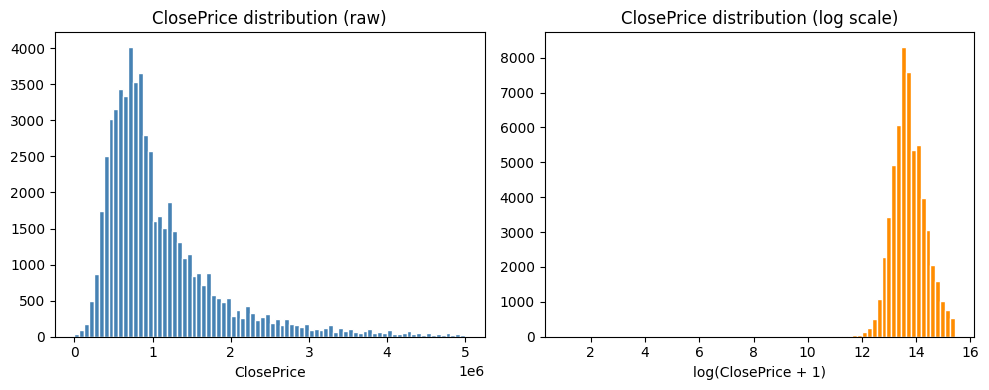

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Assuming data_dir is already defined as Path('/content/drive/MyDrive/IDXExchange_Training/data')
# We will create the 'outputs' directory inside the IDXExchange_Training directory.
output_dir = data_dir.parent / 'outputs'
output_dir.mkdir(exist_ok=True)

df_constrained = df[df['ClosePrice'] < 5_000_000].copy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_constrained['ClosePrice'], bins=80, color='steelblue', edgecolor='white')
plt.xlabel('ClosePrice')
plt.title('ClosePrice distribution (raw)')


plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_constrained['ClosePrice']), bins=80, color='darkorange',
edgecolor='white')
plt.xlabel('log(ClosePrice + 1)')
plt.title('ClosePrice distribution (log scale)')
plt.tight_layout()
plt.savefig(output_dir / 'price_distribution.png', dpi=120)
plt.show()

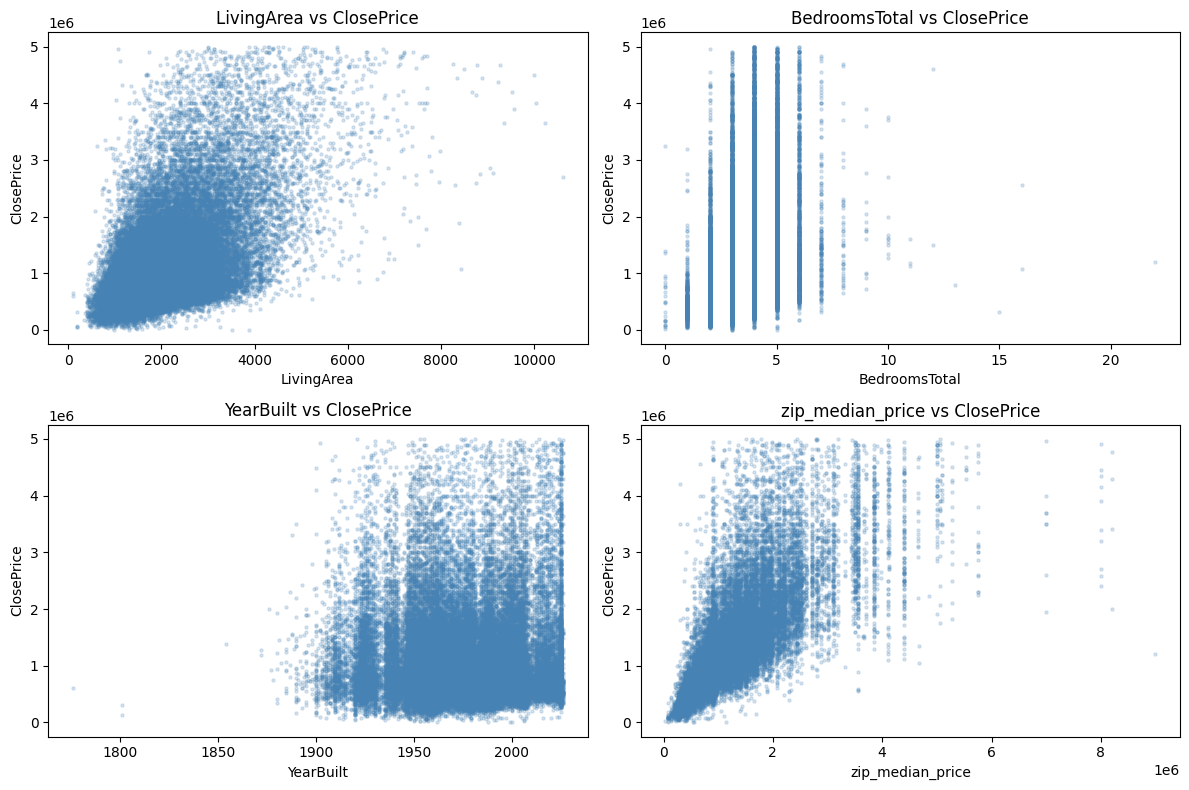

In [48]:
df_constrained = df[df['ClosePrice'] < 5_000_000].copy()

features_to_plot = ['LivingArea', 'BedroomsTotal', 'YearBuilt', 'zip_median_price']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, features_to_plot):
 ax.scatter(df_constrained[feat], df_constrained['ClosePrice'], alpha=0.2, s=5, color='steelblue')
 ax.set_xlabel(feat)
 ax.set_ylabel('ClosePrice')
 ax.set_title(f'{feat} vs ClosePrice')
plt.tight_layout()
plt.savefig(output_dir / 'feature_scatter.png', dpi=120)
plt.show()

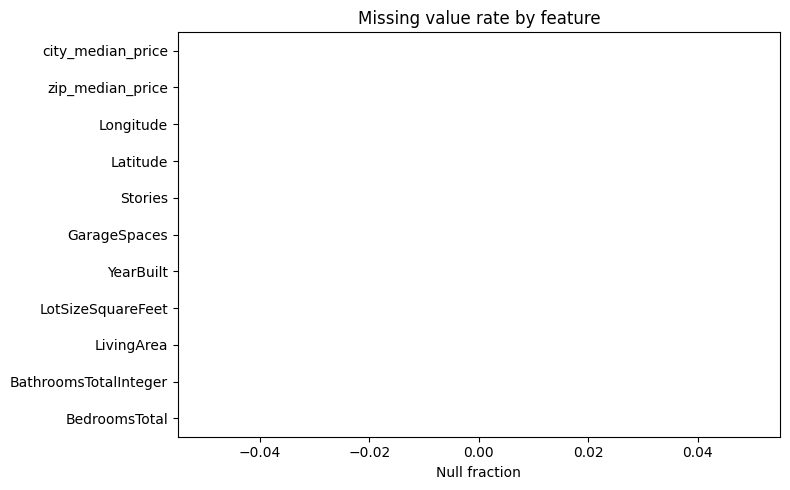

In [49]:
feature_cols = [
 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
 'Latitude', 'Longitude', 'zip_median_price', 'city_median_price'
]
null_rates = df[feature_cols].isnull().mean().sort_values()
null_rates.plot(kind='barh', figsize=(8, 5), color='tomato')
plt.xlabel('Null fraction')
plt.title('Missing value rate by feature')
plt.tight_layout()
plt.savefig(output_dir / 'null_rates.png', dpi=120)
plt.show()

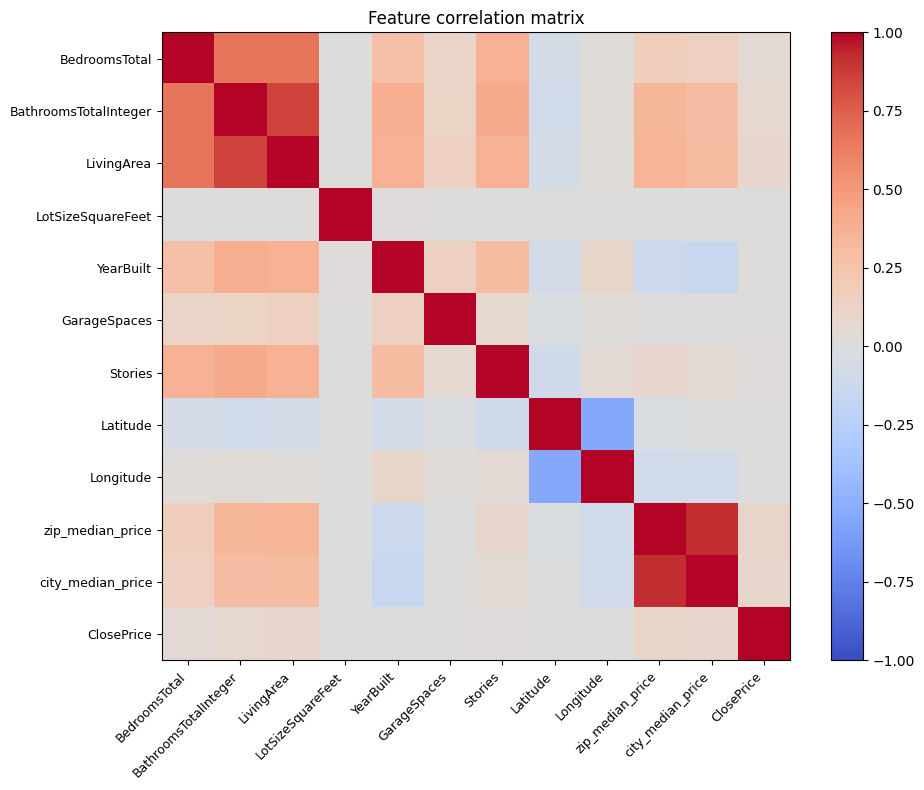

In [50]:
corr = df[feature_cols + ['ClosePrice']].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig(output_dir / 'correlation_matrix.png', dpi=120)
plt.show()

Feature Justification Table

In [51]:
import pandas as pd

justif_table = {
    'Column': ['BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea', 'LotSizeSquareFeet',
                 'YearBuilt', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude',
                 'zip_median_price', 'city_median_price'],
    'Q1: Known at prediction time?': ['Yes']*9 + ['Yes (training only)', 'Yes (training only)'],
    'Q2: Null >50%?': ['No']*11,
    'Q3: Plausible signal?': [
        'Yes: bedrooms are important for buyers',
        'Yes: independent signal from bedrooms',
        'Yes: strongest physical size signal',
        'Yes: land value affects price',
        'Yes: newer homes are more desired',
        'Yes: a desired quality',
        'Yes: provides specificity for building preferences',
        'Yes: direct location signal',
        'Yes: direct location signal',
        'Yes: provides neighborhood price levels',
        'Yes: smooths thin ZIP markets'
    ],
    'Q4: Null 10-50%?': ['No']*11,
    'Decision': [
        'Include', 'Include', 'Include',
        'Include', 'Include',
        'Include', 'Include',
        'Include', 'Include',
        'Include',
        'Include'
    ]
}

pd.DataFrame(justif_table)

,Column,Q1: Known at prediction time?,Q2: Null >50%?,Q3: Plausible signal?,Q4: Null 10-50%?,Decision
0,BedroomsTotal,Yes,No,Yes: bedrooms are important for buyers,No,Include
1,BathroomsTotalInteger,Yes,No,Yes: independent signal from bedrooms,No,Include
2,LivingArea,Yes,No,Yes: strongest physical size signal,No,Include
3,LotSizeSquareFeet,Yes,No,Yes: land value affects price,No,Include
4,YearBuilt,Yes,No,Yes: newer homes are more desired,No,Include
5,GarageSpaces,Yes,No,Yes: a desired quality,No,Include
6,Stories,Yes,No,Yes: provides specificity for building prefere...,No,Include
7,Latitude,Yes,No,Yes: direct location signal,No,Include
8,Longitude,Yes,No,Yes: direct location signal,No,Include
9,zip_median_price,Yes (training only),No,Yes: provides neighborhood price levels,No,Include


Missing-value decision table for feature column

In [55]:
import pandas as pd

missing_value_table = {
    'Column': ['BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea', 'LotSizeSquareFeet',
                 'YearBuilt', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude',
                 'zip_median_price', 'city_median_price'],
    'Null Percentage': [
        0.00,
        0.00,
        0.00,
        1.73,
        0.05,
        3.91,
        9.92,
        0.01,
        0.01,
        0.00,
        0.00
    ],
    'Decision': [
        'Drop row', 'Drop row', 'Drop row',
        'Fill with median', 'Fill with median',
        'Fill 0', 'Fill median',
        'Fill with median', 'Fill with median',
        'Investigate further',
        'Investigate further'
    ],
        'Reason': [
        'Essential feature; removed during Week 1 cleaning.',
        'Essential feature; removed during Week 1 cleaning.',
        'Essential feature; removed during Week 1 cleaning.',
        '1.73% < 50% missing, so fill with median.',
        '0.05% < 50% missing, so fill with median.',
        'A missing garage-space value can represent a property with no garage, so fill with 0.',
        '9.92% < 50% missing, so fill with median.',
        'Only 0.01% missing, so fill with median.',
        'Only 0.01% missing, so fill with median.',
        'No missing values.',
        'No missing values.'
    ]
}

pd.DataFrame(missing_value_table)

,Column,Null Percentage,Decision,Reason
0,BedroomsTotal,0.00,Drop row,Essential feature; rows missing this value wer...
1,BathroomsTotalInteger,0.00,Drop row,Essential feature; rows missing this value wer...
2,LivingArea,0.00,Drop row,Essential feature; rows missing this value wer...
3,LotSizeSquareFeet,1.73,Fill with median,"Only 1.73% missing, so median imputation prese..."
4,YearBuilt,0.05,Fill with median,"Only 0.05% missing, so median imputation is ap..."
5,GarageSpaces,3.91,Fill 0,A missing garage-space value can represent a p...
6,Stories,9.92,Fill median,The highest missing rate among the selected fe...
7,Latitude,0.01,Fill with median,"Only 0.01% missing, so median imputation prese..."
8,Longitude,0.01,Fill with median,"Only 0.01% missing, so median imputation prese..."
9,zip_median_price,0.00,Investigate further,No missing values were produced in the current...
